<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/neural_networks/lab 8 - MLP with PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Multilayer Perceptron (MLP) with PyTorch

In the NumPy lab we derived and coded the backward pass by hand. That is the best way to understand it, but it does not scale: every new layer or activation means new derivatives to work out and new code to debug. **PyTorch** removes that work with **automatic differentiation (autograd)**. You write only the forward pass, and PyTorch computes every gradient for you.

We solve the same XOR problem again, so that every PyTorch tool can be compared with the NumPy code you already know.

**Contents**

0. What PyTorch does and why it is useful
1. Data (same as the NumPy lab)
2. Tensors
3. Autograd: gradients for free
4. Autograd reproduces our hand-written backprop
5. `nn.Linear` and `nn.Module`
6. The model: an MLP with ReLU hidden layers
7. The loss: why `BCEWithLogitsLoss`
8. Training loop 1: full-batch gradient descent by hand
9. Optimisers: SGD, momentum and Adam
10. `Dataset` and `DataLoader`
11. Final version: mini-batches, Adam and a validation set
12. Useful extras: `nn.Sequential`, saving a model, GPU
13. Summary and exercises

Theory: [`notes/neural_networks/01_backpropagation`](https://imagra93.github.io/ML-course-labs/notes/neural_networks/01_backpropagation.html#automatic-differentiation) (section 13, automatic differentiation) and [`notes/neural_networks/02_training_optimization_regularization`](https://imagra93.github.io/ML-course-labs/notes/neural_networks/02_training_optimization_regularization.html) (optimisers and the training loop).

**From NumPy to PyTorch**

| Concept | NumPy lab (by hand) | PyTorch |
|---|---|---|
| Arrays | `np.ndarray` | `torch.Tensor` |
| Parameters | arrays we update ourselves | `nn.Parameter`, registered by `nn.Module` |
| Layer $\mathbf{Z} = \mathbf{A}\mathbf{W} + \mathbf{b}$ | `A @ W + b` | `nn.Linear(n_in, n_out)` |
| Forward pass | `forward` method | `forward` method, called as `model(x)` |
| Backward pass | `compute_gradients` (our chain rule) | `loss.backward()` |
| Update | `update_parameters` | `optimizer.step()` |
| Mini-batches | manual shuffling and slicing | `DataLoader` |

**Notation** (same as the NumPy lab): $m$ examples per batch, $\mathbf{W}^{[l]}, \mathbf{b}^{[l]}$ the parameters of layer $l$, $\mathbf{Z}^{[l]}$ and $\mathbf{A}^{[l]}$ its pre-activation and activation, $J$ the loss, $\alpha$ the learning rate, $\boldsymbol{\theta}$ all the parameters together.

## 0. What PyTorch does and why it is useful

Training any neural network needs four ingredients. Look at how much of each one we wrote by hand in the NumPy lab:

| Ingredient | NumPy lab | PyTorch |
|---|---|---|
| **Model**: the forward pass $\hat{y} = f_{\boldsymbol{\theta}}(\mathbf{x})$ | written by hand | written by hand, from ready-made layers |
| **Gradients** $\nabla_{\boldsymbol{\theta}} J$ | derived on paper, coded, checked with finite differences | **automatic**: `loss.backward()` |
| **Update rule** (SGD, Adam, ...) | coded by hand | ready-made: `optimizer.step()` |
| **Data pipeline** (shuffling, batches) | coded by hand | ready-made: `DataLoader` |

PyTorch is a library that gives you all four. In one sentence: **you describe the forward pass, and PyTorch does the rest.**

**What it actually does.**

1. **Tensors.** It provides `torch.Tensor`, an array like NumPy's, with the same operations (`@`, broadcasting, indexing).
2. **Automatic differentiation (autograd).** While your forward pass runs, PyTorch records every operation on tensors that need gradients, building a graph such as $\mathbf{X} \to \mathbf{Z}^{[1]} \to \mathbf{A}^{[1]} \to \dots \to J$. When you call `loss.backward()`, it walks that graph backwards applying the chain rule, which is exactly the backpropagation we derived by hand, and stores $\partial J / \partial \theta$ in every parameter's `.grad`. It knows the derivative of each elementary operation, so it can differentiate **any** composition of them.
3. **Building blocks.** `torch.nn` contains layers (`nn.Linear`, convolutions, LSTMs, attention), activations and losses, all with correct and numerically stable gradients. `torch.optim` contains the update rules. `torch.utils.data` loads and batches data.
4. **Hardware.** The same code runs on a CPU or a GPU (`.to("cuda")`). GPUs do thousands of multiplications in parallel, which makes training large networks 10 to 100 times faster.

**Why it is useful.**

- **No more hand-written backward passes.** Our 2-layer network needed a page of derivation. A modern network has hundreds of layers of different types, and deriving all of it by hand would be slow and error-prone. With autograd, changing the architecture means changing only `forward`.
- **Fast experiments.** Adding a layer, swapping ReLU for tanh or SGD for Adam is a one-line change. That is how research and real projects iterate.
- **Correct and fast by default.** The building blocks are tested and optimised in C++ and CUDA, and handle numerical traps for you (section 7 shows one).
- **It is just Python.** The graph is built as the code runs, so you can use `if`, `for`, `print` and a debugger inside the model.
- **Ecosystem.** Pretrained models (torchvision, Hugging Face), training tools (Lightning) and deployment tools (ONNX export) are all built on top of it. Most of the next labs use them.

What PyTorch does **not** do is choose the model, the loss, the learning rate or the data for you. Those are still your decisions, and the NumPy lab is what lets you understand them. The rest of this lab introduces each piece of PyTorch in turn.

In [1]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(42)
torch.manual_seed(0)
print("PyTorch", torch.__version__)

PyTorch 2.12.0+cu130


## 1. Data (same as the NumPy lab)

Points $(x_1, x_2) \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ with label $y = \mathbb{1}[x_1 x_2 > 0]$: class 1 in the first and third quadrants. No straight line separates the classes (the proof is in the NumPy lab). We use the same generator and seed as there, so the numbers are comparable. We also keep a **validation set** to measure generalisation.

In [2]:
def make_xor(n, rng):
    X = rng.normal(size=(n, 2))
    y = (X[:, 0] * X[:, 1] > 0).astype(float).reshape(-1, 1)
    return X, y

X, y = make_xor(1000, rng)          # training set
X_val, y_val = make_xor(500, rng)   # validation set
print("X:", X.shape, " y:", y.shape, " X_val:", X_val.shape)

X: (1000, 2)  y: (1000, 1)  X_val: (500, 2)


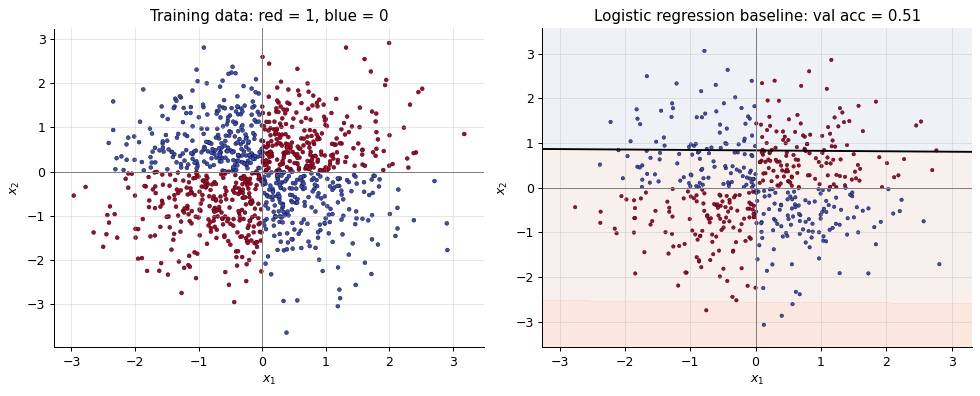

In [3]:
from sklearn.linear_model import LogisticRegression

def scatter_classes(ax, X, y, s=10):
    ax.scatter(X[:, 0], X[:, 1], c=np.ravel(y), cmap="coolwarm", s=s, edgecolors="k", linewidths=0.3)
    ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")

def plot_boundary(ax, predict_proba, X, y, title=""):
    """Background = predicted P(y=1 | x); black line = decision boundary P = 0.5.
    predict_proba takes a NumPy array of shape (k, 2) and returns k probabilities."""
    x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 250)
    x2 = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 250)
    G1, G2 = np.meshgrid(x1, x2)
    P = np.asarray(predict_proba(np.c_[G1.ravel(), G2.ravel()])).reshape(G1.shape)
    ax.contourf(G1, G2, P, levels=np.linspace(0, 1, 11), cmap="coolwarm", alpha=0.35)
    ax.contour(G1, G2, P, levels=[0.5], colors="k", linewidths=1.5)
    scatter_classes(ax, X, y, s=8)
    ax.set_title(title)

logreg = LogisticRegression().fit(X, y.ravel())
acc_lr = logreg.score(X_val, y_val.ravel())
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
scatter_classes(axes[0], X, y); axes[0].set_title("Training data: red = 1, blue = 0")
plot_boundary(axes[1], lambda G: logreg.predict_proba(G)[:, 1], X_val, y_val,
              f"Logistic regression baseline: val acc = {acc_lr:.2f}")
plt.tight_layout(); plt.show()

As in the NumPy lab, the linear model is no better than guessing. Now let us build the MLP in PyTorch, starting from the basic object: the tensor.

## 2. Tensors

A `torch.Tensor` is PyTorch's version of a NumPy array: same indexing, broadcasting and matrix product `@`. It adds two things:
- it can live on a **GPU** (`tensor.to("cuda")`);
- it can **record the operations** applied to it, so that gradients can be computed later (section 3).

Two details that cause many beginner bugs:
- **dtype.** NumPy defaults to `float64`, PyTorch layers use `float32`. Mixing them raises an error, so convert with `dtype=torch.float32`.
- **Shapes.** Layers expect a batch dimension first: one example of 2 features has shape `(1, 2)`, not `(2,)`. Our labels have shape `(m, 1)`, the same as the network output.

In [4]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
print("X_tensor:", X_tensor.shape, X_tensor.dtype, "  y_tensor:", y_tensor.shape)

# Tensors behave like NumPy arrays
a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print("a @ a =\n", a @ a)
print("a.sum(dim=0) =", a.sum(dim=0), "  (dim plays the role of NumPy's axis)")
print("back to NumPy:", a.numpy().dtype, type(a.numpy()))

X_tensor: torch.Size([1000, 2]) torch.float32   y_tensor: torch.Size([1000, 1])
a @ a =
 tensor([[ 7., 10.],
        [15., 22.]])
a.sum(dim=0) = tensor([4., 6.])   (dim plays the role of NumPy's axis)
back to NumPy: float32 <class 'numpy.ndarray'>


## 3. Autograd: gradients for free

If a tensor is created with `requires_grad=True`, PyTorch records every operation that uses it, building a **computational graph** while the code runs. Calling `.backward()` on a scalar result walks that graph backwards with the chain rule, exactly what we did by hand in the NumPy lab, and stores $\partial(\text{result})/\partial(\text{tensor})$ in each tensor's `.grad`.

Small example: $z = w x + b$ and $L = z^2$ with $x = 2$, $w = 3$, $b = 1$. By hand, $z = 7$ and

$$
\frac{\partial L}{\partial w} = 2z \cdot x = 28, \qquad \frac{\partial L}{\partial b} = 2z = 14 .
$$

In [5]:
x = torch.tensor(2.0)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

z = w * x + b          # PyTorch records: mul, then add
L = z ** 2             # ... then pow
print("L =", L.item(), "  grad_fn:", L.grad_fn)   # the last recorded operation

L.backward()           # chain rule, from L back to w and b
print("dL/dw =", w.grad.item(), "  (expected 28)")
print("dL/db =", b.grad.item(), "  (expected 14)")

L = 49.0   grad_fn: <PowBackward0 object at 0x78fa4a6bd870>


dL/dw = 28.0   (expected 28)
dL/db = 14.0   (expected 14)


**Gradients accumulate.** `.backward()` **adds** to `.grad`, it does not overwrite it. That is useful in some advanced cases (summing gradients over several small batches), but in a normal training loop you must reset the gradients before every backward pass. Otherwise each step would use the sum of all past gradients.

In [6]:
L = (w * x + b) ** 2
L.backward()
print("after a second backward, without zeroing: dL/dw =", w.grad.item(), " (28 + 28)")

w.grad.zero_(); b.grad.zero_()      # what optimizer.zero_grad() does for every parameter
L = (w * x + b) ** 2
L.backward()
print("after zeroing first:                      dL/dw =", w.grad.item())

after a second backward, without zeroing: dL/dw = 56.0  (28 + 28)
after zeroing first:                      dL/dw = 28.0


**Switching recording off.** Two tools you will use constantly:
- `with torch.no_grad():` runs code without building a graph. Use it for evaluation, for predictions and for updating the weights by hand (the update itself must not be differentiated).
- `tensor.detach()` returns the same values cut off from the graph, for example to store a loss value or convert it to NumPy. `loss.item()` does the same for a scalar and returns a Python float.

In [7]:
with torch.no_grad():
    z = w * x + b
print("inside no_grad: z.requires_grad =", z.requires_grad)
print("outside:        (w * x + b).requires_grad =", (w * x + b).requires_grad)
print("detached:       (w * x + b).detach().requires_grad =", (w * x + b).detach().requires_grad)

inside no_grad: z.requires_grad = False
outside:        (w * x + b).requires_grad = True
detached:       (w * x + b).detach().requires_grad = False


## 4. Autograd reproduces our hand-written backprop

Let us check that autograd gives **exactly** the gradients we derived in the NumPy lab. We build the same $2 \to 4 \to 1$ sigmoid network with raw tensors, compute the mean BCE loss, and compare `.grad` with the formulas

$$
\boldsymbol{\delta}^{[2]} = \tfrac{1}{m}(\mathbf{A}^{[2]} - \mathbf{y}), \quad
\frac{\partial J}{\partial \mathbf{W}^{[2]}} = \mathbf{A}^{[1]\top}\boldsymbol{\delta}^{[2]}, \quad
\boldsymbol{\delta}^{[1]} = (\boldsymbol{\delta}^{[2]}\mathbf{W}^{[2]\top}) \odot \mathbf{A}^{[1]} \odot (1 - \mathbf{A}^{[1]}), \quad
\frac{\partial J}{\partial \mathbf{W}^{[1]}} = \mathbf{X}^\top\boldsymbol{\delta}^{[1]},
$$

with the biases getting the row sums of the $\boldsymbol{\delta}$'s. We use `float64` so that the comparison is not limited by rounding.

In [8]:
g = torch.Generator().manual_seed(1)
Xs = torch.tensor(X[:20], dtype=torch.float64)
ys = torch.tensor(y[:20], dtype=torch.float64)
W1 = torch.randn(2, 4, dtype=torch.float64, generator=g, requires_grad=True)
b1 = torch.zeros(1, 4, dtype=torch.float64, requires_grad=True)
W2 = torch.randn(4, 1, dtype=torch.float64, generator=g, requires_grad=True)
b2 = torch.zeros(1, 1, dtype=torch.float64, requires_grad=True)

# Forward pass, written exactly as in the NumPy lab
A1 = torch.sigmoid(Xs @ W1 + b1)
A2 = torch.sigmoid(A1 @ W2 + b2)
J = F.binary_cross_entropy(A2, ys)       # mean BCE
J.backward()                             # autograd

# Backward pass by hand (NumPy lab formulas)
with torch.no_grad():
    m = Xs.shape[0]
    d2 = (A2 - ys) / m
    dW2, db2 = A1.T @ d2, d2.sum(0, keepdim=True)
    d1 = (d2 @ W2.T) * A1 * (1 - A1)
    dW1, db1 = Xs.T @ d1, d1.sum(0, keepdim=True)

for name, auto, manual in [("W1", W1.grad, dW1), ("b1", b1.grad, db1), ("W2", W2.grad, dW2), ("b2", b2.grad, db2)]:
    print(f"{name}: max |autograd - by hand| = {(auto - manual).abs().max().item():.1e}")

W1: max |autograd - by hand| = 5.9e-18
b1: max |autograd - by hand| = 2.8e-17
W2: max |autograd - by hand| = 2.8e-17
b2: max |autograd - by hand| = 0.0e+00


The two agree to machine precision. Autograd is not an approximation: it applies the same chain rule, mechanically, to whatever forward pass we write. From now on we never write a backward pass again.

## 5. `nn.Linear` and `nn.Module`

**`nn.Linear(n_in, n_out)`** is one fully connected layer: it holds a weight and a bias as `nn.Parameter`s (tensors with `requires_grad=True`) and computes an affine map. One convention differs from the NumPy lab: PyTorch stores the weight as `(n_out, n_in)` and computes

$$
\text{Linear}(\mathbf{X}) = \mathbf{X}\,\mathbf{W}_{\text{torch}}^\top + \mathbf{b},
$$

so `layer.weight.T` is our $\mathbf{W}^{[l]}$. The result is the same.

**Default initialisation.** PyTorch draws the weights and biases uniformly from $\big[-1/\sqrt{n_{\text{in}}},\; 1/\sqrt{n_{\text{in}}}\big]$. Random values break the symmetry between units, and the $1/\sqrt{n_{\text{in}}}$ scale keeps $Z$ of the order of 1 whatever the layer width (the Xavier/He derivation is in the notes).

In [9]:
layer = nn.Linear(2, 4)
print("weight shape:", tuple(layer.weight.shape), " bias shape:", tuple(layer.bias.shape))
print("weight is a Parameter:", isinstance(layer.weight, nn.Parameter), " requires_grad:", layer.weight.requires_grad)

xb = X_tensor[:3]
same = torch.allclose(layer(xb), xb @ layer.weight.T + layer.bias)
print("layer(x) == x @ W.T + b :", same)

weight shape: (4, 2)  bias shape: (4,)
weight is a Parameter: True  requires_grad: True
layer(x) == x @ W.T + b : True


**`nn.Module`** is the base class of every model in PyTorch. To define a network you write a class with two methods:
- `__init__`: create the layers. Any `nn.Linear` (or other module) assigned as an attribute is **registered** automatically, so `model.parameters()` finds all its weights. That is what we give to the optimiser.
- `forward(x)`: the computation. You call the model as `model(x)`, never `model.forward(x)` directly: `model(x)` also runs PyTorch's internal hooks.

The module also has `model.train()` and `model.eval()` modes. They change the behaviour of layers such as dropout and batch normalisation. Our model has neither, but it is a good habit to call them.

## 6. The model: an MLP with ReLU hidden layers

We use two hidden layers of 4 units and **ReLU** activations:

$$
\mathbf{A}^{[1]} = \text{ReLU}(\mathbf{X}\mathbf{W}^{[1]} + \mathbf{b}^{[1]}), \qquad
\mathbf{A}^{[2]} = \text{ReLU}(\mathbf{A}^{[1]}\mathbf{W}^{[2]} + \mathbf{b}^{[2]}), \qquad
\mathbf{Z}^{[3]} = \mathbf{A}^{[2]}\mathbf{W}^{[3]} + \mathbf{b}^{[3]} .
$$

Two differences from the NumPy lab:
- **ReLU instead of sigmoid in the hidden layers.** $\text{ReLU}(z) = \max(0, z)$ has derivative 1 for active units, so gradients do not shrink as they go back through the layers. It is the default choice for hidden layers.
- **The output is a logit, not a probability.** `forward` returns $\mathbf{Z}^{[3]} \in \mathbb{R}$ with no sigmoid. The sigmoid is applied inside the loss (section 7), and we apply it ourselves when we want a probability, $\hat{y} = \sigma(Z^{[3]})$.

The lines that were blank in the original lab are filled in and marked with `# <-`.

In [10]:
class simpleMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)    # W1: 2 -> 4
        self.fc2 = nn.Linear(hidden_size, hidden_size)   # W2: 4 -> 4
        self.fc3 = nn.Linear(hidden_size, output_size)   # W3: 4 -> 1

    def forward(self, x):
        x = self.fc1(x)       # <- Z1 = X W1 + b1
        x = F.relu(x)         #    A1 = ReLU(Z1)
        x = self.fc2(x)       # <- Z2 = A1 W2 + b2
        x = F.relu(x)         #    A2 = ReLU(Z2)
        x = self.fc3(x)       # <- Z3 = A2 W3 + b3  (logit, no sigmoid)
        return x

input_size, hidden_size, output_size = 2, 4, 1
torch.manual_seed(0)
model = simpleMLP(input_size, hidden_size, output_size)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nnumber of parameters: {n_params}  (= 2*4+4  +  4*4+4  +  4*1+1)")
for name, p in model.named_parameters():
    print(f"  {name:<11} shape {tuple(p.shape)}")

simpleMLP(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=4, bias=True)
  (fc3): Linear(in_features=4, out_features=1, bias=True)
)

number of parameters: 37  (= 2*4+4  +  4*4+4  +  4*1+1)
  fc1.weight  shape (4, 2)
  fc1.bias    shape (4,)
  fc2.weight  shape (4, 4)
  fc2.bias    shape (4,)
  fc3.weight  shape (1, 4)
  fc3.bias    shape (1,)


In [11]:
with torch.no_grad():
    logits = model(X_tensor[:3])
print("logits (any real number):  ", logits.ravel())
print("probabilities (sigmoid):   ", torch.sigmoid(logits).ravel())

logits (any real number):   tensor([-0.5286, -0.4012, -0.8817])
probabilities (sigmoid):    tensor([0.3709, 0.4010, 0.2928])


## 7. The loss: why `BCEWithLogitsLoss`

The loss is the same binary cross-entropy as in the NumPy lab. `nn.BCEWithLogitsLoss` takes the **logit** $z$ and applies the sigmoid internally. Why not apply `torch.sigmoid` in the model and use `nn.BCELoss`? Numerical stability.

Substituting $\hat{y} = \sigma(z)$ into the loss of one example, using $\log\sigma(z) = -\log(1 + e^{-z})$ and $\log(1 - \sigma(z)) = -z - \log(1 + e^{-z})$:

$$
\ell(z, y) = -\big[y\log\sigma(z) + (1 - y)\log(1 - \sigma(z))\big] = \log(1 + e^{z}) - y\,z = \max(z, 0) - y\,z + \log\big(1 + e^{-|z|}\big).
$$

The last form never computes $\log 0$ and never overflows, for any $z$. With sigmoid first, a large logit such as $z = 200$ gives $\sigma(z) = 1$ exactly in floating point, and then $\log(1 - \sigma(z)) = \log 0 = -\infty$. `nn.BCELoss` clamps the log at $-100$, which hides the problem but returns a wrong loss and a zero gradient.

A bonus of the logit form: its gradient is simply $\partial\ell/\partial z = \sigma(z) - y$, the same "prediction minus label" we derived by hand.

In [12]:
z = torch.tensor([[200.0], [5.0]], requires_grad=True)   # very confident logits...
t = torch.tensor([[0.0], [0.0]])                          # ...for examples of class 0 (so, very wrong)

loss_logits = nn.BCEWithLogitsLoss(reduction="none")(z, t)
print("BCEWithLogitsLoss         :", loss_logits.detach().ravel(), " (exact: log(1+e^z) = 200 and 5.007)")
loss_logits.sum().backward()
print("  gradient dl/dz          :", z.grad.ravel(), " (sigma(z) - y)")

z.grad = None
loss_prob = nn.BCELoss(reduction="none")(torch.sigmoid(z), t)
print("sigmoid + BCELoss         :", loss_prob.detach().ravel(), " (first value clamped, wrong)")
loss_prob.sum().backward()
print("  gradient dl/dz          :", z.grad.ravel(), " (first gradient lost)")

BCEWithLogitsLoss         : tensor([200.0000,   5.0067])  (exact: log(1+e^z) = 200 and 5.007)
  gradient dl/dz          : tensor([1.0000, 0.9933])  (sigma(z) - y)
sigmoid + BCELoss         : tensor([100.0000,   5.0067])  (first value clamped, wrong)
  gradient dl/dz          : tensor([0.0000, 0.9933])  (first gradient lost)


**Rule:** for binary classification, return logits from the model and use `nn.BCEWithLogitsLoss`. For multi-class, the same idea gives `nn.CrossEntropyLoss`, which takes raw logits and applies the softmax internally.

## 8. Training loop 1: full-batch gradient descent by hand

Every PyTorch training loop has the same five steps. Compare them with the NumPy lab:

| Step | PyTorch | NumPy lab |
|---|---|---|
| 1. forward | `outputs = model(X)` | `mlp.forward(X)` |
| 2. loss | `loss = criterion(outputs, y)` | `binary_cross_entropy(y, A2)` |
| 3. reset gradients | `model.zero_grad()` | not needed (we overwrote them) |
| 4. backward | `loss.backward()` | `mlp.compute_gradients(X, y)` |
| 5. update | `param -= lr * param.grad` inside `torch.no_grad()` | `mlp.update_parameters()` |

To start we do plain gradient descent on the full training set at every step, with the update written by hand. The update is inside `torch.no_grad()` because it is not part of the model: we do not want autograd to record it.

In [13]:
torch.manual_seed(0)
model = simpleMLP(input_size, hidden_size, output_size)
criterion = nn.BCEWithLogitsLoss()
learning_rate = 0.1
epochs = 5000
loss_history = []

for epoch in range(epochs):
    outputs = model(X_tensor)                  # 1. forward pass (logits)
    loss = criterion(outputs, y_tensor)        # 2. loss

    model.zero_grad()                          # 3. reset the gradients
    loss.backward()                            # 4. backward pass: fills p.grad for every parameter
    loss_history.append(loss.item())

    with torch.no_grad():                      # 5. gradient descent step, not recorded
        for param in model.parameters():
            param -= learning_rate * param.grad

    if epoch % 500 == 0 or epoch == epochs - 1:
        print(f"epoch [{epoch + 1}/{epochs}]  loss: {loss.item():.4f}")

epoch [1/5000]  loss: 0.7579
epoch [501/5000]  loss: 0.2666


epoch [1001/5000]  loss: 0.1261
epoch [1501/5000]  loss: 0.0871


epoch [2001/5000]  loss: 0.0690
epoch [2501/5000]  loss: 0.0577


epoch [3001/5000]  loss: 0.0499
epoch [3501/5000]  loss: 0.0441


epoch [4001/5000]  loss: 0.0397
epoch [4501/5000]  loss: 0.0362


epoch [5000/5000]  loss: 0.0333


**Evaluating.** Predictions do not need gradients, so we use `torch.no_grad()`. The predicted class is $\mathbb{1}[\sigma(z) > 0.5]$, which is the same as $\mathbb{1}[z > 0]$. We write two small helpers that we reuse for every model.

train accuracy: 0.992
val accuracy:   0.992


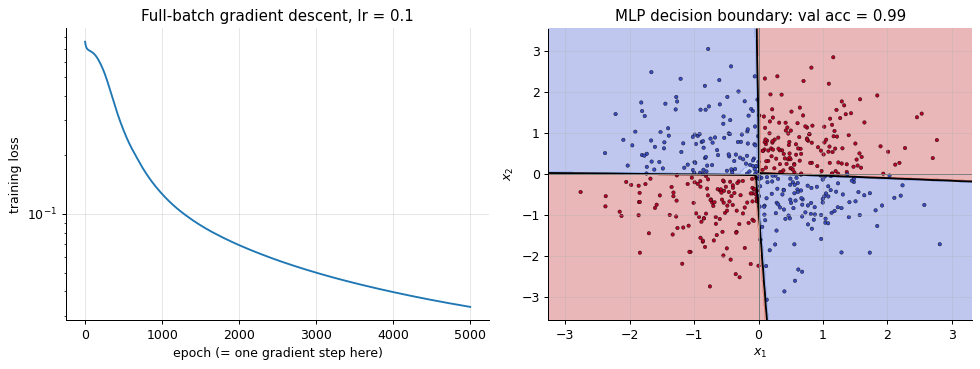

In [14]:
def accuracy(model, X_t, y_t):
    model.eval()
    with torch.no_grad():
        predicted = (torch.sigmoid(model(X_t)) > 0.5).float()
    return (predicted == y_t).float().mean().item()

def torch_proba(model):
    """Wrap a model as a NumPy -> NumPy probability function, for plot_boundary."""
    def f(G):
        model.eval()
        with torch.no_grad():
            return torch.sigmoid(model(torch.tensor(G, dtype=torch.float32))).numpy().ravel()
    return f

print(f"train accuracy: {accuracy(model, X_tensor, y_tensor):.3f}")
print(f"val accuracy:   {accuracy(model, X_val_tensor, y_val_tensor):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(loss_history); axes[0].set_yscale("log")
axes[0].set_xlabel("epoch (= one gradient step here)"); axes[0].set_ylabel("training loss")
axes[0].set_title("Full-batch gradient descent, lr = 0.1")
plot_boundary(axes[1], torch_proba(model), X_val, y_val,
              f"MLP decision boundary: val acc = {accuracy(model, X_val_tensor, y_val_tensor):.2f}")
plt.tight_layout(); plt.show()

The ReLU network also solves the task. Notice the shape of the boundary: ReLU units are piecewise linear, so the network is a **piecewise linear** function of the input and its boundary is made of straight segments. The sigmoid network of the NumPy lab gave smooth curves.

## 9. Optimisers: SGD, momentum and Adam

Writing the update by hand gets tedious, and plain gradient descent is rarely the best choice. `torch.optim` contains the standard update rules. Each optimiser receives `model.parameters()`, the list of tensors it must update, and provides two methods: `optimizer.zero_grad()` (step 3) and `optimizer.step()` (step 5). With $\mathbf{g}_t = \nabla_{\boldsymbol{\theta}} J$ at step $t$:

**SGD** (`torch.optim.SGD(params, lr)`): the update we wrote by hand,

$$
\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \alpha\,\mathbf{g}_t .
$$

**SGD with momentum** (`torch.optim.SGD(params, lr, momentum=0.9)`): keep a running "velocity" $\mathbf{v}$ that accumulates past gradients,

$$
\mathbf{v}_t = \mu\,\mathbf{v}_{t-1} + \mathbf{g}_t, \qquad \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \alpha\,\mathbf{v}_t .
$$

Like a ball rolling downhill: in directions where the gradient keeps the same sign the steps add up (up to $1/(1-\mu) = 10$ times larger for $\mu = 0.9$), and in directions where it oscillates they cancel. It helps across plateaus and long narrow valleys.

**Adam** (`torch.optim.Adam(params, lr)`): momentum plus a separate step size for every parameter,

$$
\begin{aligned}
\mathbf{m}_t &= \beta_1\mathbf{m}_{t-1} + (1 - \beta_1)\,\mathbf{g}_t &&\text{(running mean of the gradient)}\\
\mathbf{v}_t &= \beta_2\mathbf{v}_{t-1} + (1 - \beta_2)\,\mathbf{g}_t^2 &&\text{(running mean of the squared gradient, element-wise)}\\
\hat{\mathbf{m}}_t &= \frac{\mathbf{m}_t}{1 - \beta_1^t}, \quad \hat{\mathbf{v}}_t = \frac{\mathbf{v}_t}{1 - \beta_2^t} &&\text{(bias correction: } \mathbf{m}_0 = \mathbf{v}_0 = \mathbf{0}\text{)}\\
\boldsymbol{\theta} &\leftarrow \boldsymbol{\theta} - \alpha\,\frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t} + \varepsilon} .
\end{aligned}
$$

Defaults: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\varepsilon = 10^{-8}$. The ratio $\hat{\mathbf{m}}/\sqrt{\hat{\mathbf{v}}}$ is roughly $\pm 1$ when the gradient is consistent, so every parameter moves by about $\alpha$ per step **whatever the scale of its gradient**. Parameters with tiny gradients are not left behind. That makes Adam robust and the usual first choice. Typical learning rates: $10^{-3}$ to $10^{-2}$.

**Bias correction, in one line:** at $t = 1$, $\mathbf{m}_1 = (1 - \beta_1)\mathbf{g}_1 = 0.1\,\mathbf{g}_1$ is ten times too small because it started at 0. Dividing by $1 - \beta_1^1 = 0.1$ fixes that. For large $t$ the correction tends to 1.

We compare the three from the **same initial weights**, with full-batch steps.

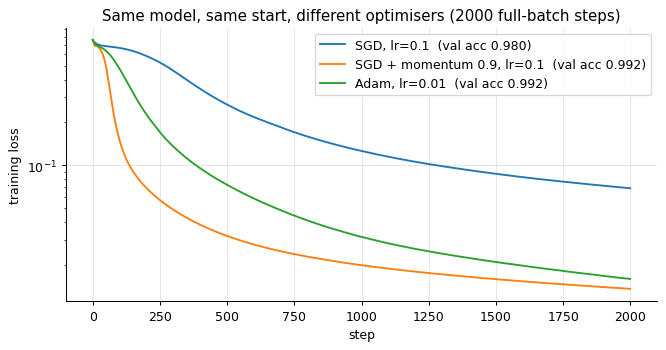

In [15]:
torch.manual_seed(0)
init_model = simpleMLP(input_size, hidden_size, output_size)

def train_full_batch(model, optimizer, epochs=2000):
    criterion = nn.BCEWithLogitsLoss()
    history = []
    for _ in range(epochs):
        optimizer.zero_grad()                         # 3. reset gradients
        loss = criterion(model(X_tensor), y_tensor)   # 1-2. forward and loss
        loss.backward()                               # 4. backward
        optimizer.step()                              # 5. update
        history.append(loss.item())
    return history

optimizers = {
    "SGD, lr=0.1":                 lambda p: torch.optim.SGD(p, lr=0.1),
    "SGD + momentum 0.9, lr=0.1":  lambda p: torch.optim.SGD(p, lr=0.1, momentum=0.9),
    "Adam, lr=0.01":               lambda p: torch.optim.Adam(p, lr=0.01),
}
results = {}
fig, ax = plt.subplots(figsize=(7.5, 4))
for name, make_opt in optimizers.items():
    net = copy.deepcopy(init_model)                   # identical starting weights
    hist = train_full_batch(net, make_opt(net.parameters()))
    results[name] = net
    ax.plot(hist, label=f"{name}  (val acc {accuracy(net, X_val_tensor, y_val_tensor):.3f})")
ax.set_yscale("log"); ax.set_xlabel("step"); ax.set_ylabel("training loss"); ax.legend()
ax.set_title("Same model, same start, different optimisers (2000 full-batch steps)")
plt.tight_layout(); plt.show()

Momentum and Adam reach a given loss in far fewer steps than plain SGD. A very low **training** loss is not the goal in itself, though: what matters is the validation accuracy, which is similar for all of them on this easy problem. On harder problems the choice of optimiser and learning rate matters much more.

`model.named_parameters()` lets us look inside a trained model. Compare the size of the weights with the ones PyTorch drew at initialisation, of order $1/\sqrt{n_{\text{in}}}$:

In [16]:
adam_model = results["Adam, lr=0.01"]
for (name, p0), (_, p) in zip(init_model.named_parameters(), adam_model.named_parameters()):
    print(f"{name:<11} mean |initial| = {p0.abs().mean().item():.2f}   mean |trained| = {p.abs().mean().item():.2f}")

fc1.weight  mean |initial| = 0.32   mean |trained| = 3.63
fc1.bias    mean |initial| = 0.15   mean |trained| = 0.03
fc2.weight  mean |initial| = 0.26   mean |trained| = 1.49
fc2.bias    mean |initial| = 0.27   mean |trained| = 0.72
fc3.weight  mean |initial| = 0.34   mean |trained| = 1.65
fc3.bias    mean |initial| = 0.29   mean |trained| = 5.70


Training has made the weights much larger. As in the NumPy lab, on data that is almost separable the cross-entropy keeps rewarding more confident predictions, so the weights grow. Regularisation such as weight decay (see the notes) is the usual way to limit this.

## 10. `Dataset` and `DataLoader`

So far every step used all 1000 examples. With real data (millions of images) that is impossible, and it is also wasteful: as we saw in the NumPy lab, many cheap steps on **mini-batches** usually beat a few exact ones. PyTorch separates two jobs:

- A **`Dataset`** knows how many examples there are (`__len__`) and how to return example number `idx` (`__getitem__`). For images it might read a file from disk here.
- A **`DataLoader`** wraps a dataset and yields **batches**: it groups examples, stacks them into tensors and, with `shuffle=True`, uses a new random order every epoch. It can also load data in parallel (`num_workers`).

In [17]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

class MyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = MyDataset(X, y)
sample_x, sample_y = dataset[0]
print(f"len(dataset) = {len(dataset)}")
print(f"dataset[0]   = X: {sample_x}, y: {sample_y}")
print("dataset[1:4] =", dataset[1:4], " (slicing works here because tensors support it)")

len(dataset) = 1000
dataset[0]   = X: tensor([ 0.3047, -1.0400]), y: tensor([0.])
dataset[1:4] = (tensor([[ 0.7505,  0.9406],
        [-1.9510, -1.3022],
        [ 0.1278, -0.3162]]), tensor([[1.],
        [1.],
        [0.]]))  (slicing works here because tensors support it)


In [18]:
batch_size = 128
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

for batch_X, batch_y in dataloader:
    print(f"batch X: {tuple(batch_X.shape)},  batch y: {tuple(batch_y.shape)}")
print(f"\nlen(dataloader) = {len(dataloader)} batches per epoch = ceil({len(dataset)} / {batch_size})")

batch X: (128, 2),  batch y: (128, 1)
batch X: (128, 2),  batch y: (128, 1)
batch X: (128, 2),  batch y: (128, 1)
batch X: (128, 2),  batch y: (128, 1)
batch X: (128, 2),  batch y: (128, 1)
batch X: (128, 2),  batch y: (128, 1)
batch X: (128, 2),  batch y: (128, 1)
batch X: (104, 2),  batch y: (104, 1)

len(dataloader) = 8 batches per epoch = ceil(1000 / 128)


The last batch is smaller ($1000 = 7 \cdot 128 + 104$). That is fine because the loss is a mean over the batch. Pass `drop_last=True` if you prefer to drop it.

For data that is already in tensors, `TensorDataset(X_tensor, y_tensor)` does exactly what `MyDataset` does. Writing your own `Dataset` class pays off when examples must be loaded or transformed one by one (images from disk, text tokenisation, data augmentation).

## 11. Final version: mini-batches, Adam and a validation set

Now we put everything together, the way real projects are written:
- a `DataLoader` with shuffled mini-batches for training;
- the Adam optimiser;
- after every epoch, the loss on the **validation** set in `eval` mode and without gradients;
- the average training loss of the epoch, weighted by batch size.

Wrapping the loop in a function makes it reusable for any model and data.

In [19]:
def fit(model, train_loader, X_val_t, y_val_t, optimizer, epochs, print_every=50):
    criterion = nn.BCEWithLogitsLoss()
    history = {"train": [], "val": []}
    for epoch in range(epochs):
        model.train()                                   # training mode
        total, count = 0.0, 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()                       # 3. reset gradients
            loss = criterion(model(batch_X), batch_y)   # 1-2. forward and loss
            loss.backward()                             # 4. backward
            optimizer.step()                            # 5. update
            total += loss.item() * len(batch_X); count += len(batch_X)
        history["train"].append(total / count)          # mean training loss over the epoch

        model.eval()                                    # evaluation mode
        with torch.no_grad():
            history["val"].append(criterion(model(X_val_t), y_val_t).item())
        if (epoch + 1) % print_every == 0:
            print(f"epoch [{epoch + 1}/{epochs}]  train loss {history['train'][-1]:.4f}   val loss {history['val'][-1]:.4f}")
    return history

torch.manual_seed(0)
model = simpleMLP(input_size, hidden_size, output_size)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
train_loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=128, shuffle=True)
history = fit(model, train_loader, X_val_tensor, y_val_tensor, optimizer, epochs=300)

epoch [50/300]  train loss 0.1377   val loss 0.1461


epoch [100/300]  train loss 0.0785   val loss 0.0923


epoch [150/300]  train loss 0.0559   val loss 0.0670


epoch [200/300]  train loss 0.0441   val loss 0.0618


epoch [250/300]  train loss 0.0363   val loss 0.0581


epoch [300/300]  train loss 0.0322   val loss 0.0461


train accuracy 0.993   val accuracy 0.988   (logistic regression: 0.510)


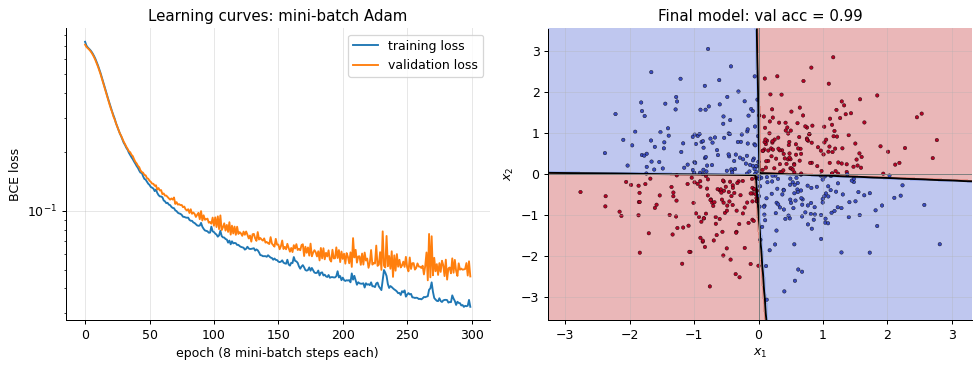

In [20]:
acc_tr, acc_va = accuracy(model, X_tensor, y_tensor), accuracy(model, X_val_tensor, y_val_tensor)
print(f"train accuracy {acc_tr:.3f}   val accuracy {acc_va:.3f}   (logistic regression: {acc_lr:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(history["train"], label="training loss")
axes[0].plot(history["val"], label="validation loss")
axes[0].set_yscale("log"); axes[0].set_xlabel("epoch (8 mini-batch steps each)"); axes[0].set_ylabel("BCE loss")
axes[0].legend(); axes[0].set_title("Learning curves: mini-batch Adam")
plot_boundary(axes[1], torch_proba(model), X_val, y_val, f"Final model: val acc = {acc_va:.2f}")
plt.tight_layout(); plt.show()

**Reading the curves.** If both losses fall together, the model is still learning patterns that generalise. If the validation loss starts rising while the training loss keeps falling, the model is **overfitting**: it memorises the training points. The usual responses are to stop training at the best validation epoch (**early stopping**), add regularisation (weight decay, dropout) or get more data. Look at your plot and decide which situation you are in.

## 12. Useful extras

### `nn.Sequential`

For a plain stack of layers you do not need to write a class. `nn.Sequential` chains modules in order, and its `forward` is implied. This model is identical to `simpleMLP`:

In [21]:
seq_model = nn.Sequential(
    nn.Linear(2, 4), nn.ReLU(),
    nn.Linear(4, 4), nn.ReLU(),
    nn.Linear(4, 1),
)
print(seq_model)

# Copy the trained weights over: same architecture, so the parameter names map one to one
seq_model.load_state_dict({k_seq: v for k_seq, v in zip(seq_model.state_dict(), model.state_dict().values())})
with torch.no_grad():
    print("same outputs as the trained simpleMLP:", torch.allclose(seq_model(X_val_tensor), model(X_val_tensor)))

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
)
same outputs as the trained simpleMLP: True


### Saving and loading a model

A model's learned state is its `state_dict()`: a dictionary from parameter names to tensors. Save that, not the whole object. To load it, create the same architecture and call `load_state_dict`.

In [22]:
import os, tempfile
path = os.path.join(tempfile.gettempdir(), "xor_mlp.pt")
torch.save(model.state_dict(), path)

restored = simpleMLP(input_size, hidden_size, output_size)
restored.load_state_dict(torch.load(path))
print("state_dict keys:", list(model.state_dict().keys()))
print(f"restored model val accuracy: {accuracy(restored, X_val_tensor, y_val_tensor):.3f}")

state_dict keys: ['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias']
restored model val accuracy: 0.988


### Predicting new points

A trained model is used like any function: build a float32 tensor of shape `(k, 2)`, run it without gradients, apply the sigmoid to get probabilities.

In [23]:
new_points = torch.tensor([[1.0, 1.0], [-1.0, 1.0], [-2.0, -0.5], [0.05, -0.05]])
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(new_points)).ravel()
for p_xy, p in zip(new_points.tolist(), probs.tolist()):
    print(f"x = ({p_xy[0]:+.2f}, {p_xy[1]:+.2f})   P(y=1) = {p:.3f}   ->  class {int(p > 0.5)}")

x = (+1.00, +1.00)   P(y=1) = 0.997   ->  class 1
x = (-1.00, +1.00)   P(y=1) = 0.000   ->  class 0
x = (-2.00, -0.50)   P(y=1) = 0.997   ->  class 1
x = (+0.05, -0.05)   P(y=1) = 0.015   ->  class 0


All four answers are correct. Be careful with the confidence, though. The last point lies very close to the origin, where the four quadrants meet, and a tiny shift would change its true class. The model still says "class 0 with 98.5% probability". A neural network's probability is not automatically a reliable measure of uncertainty, especially near the boundary or far from the training data.

### Running on a GPU

The model and every batch must live on the same **device**. The usual pattern:

```python
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)                    # moves all parameters
for batch_X, batch_y in train_loader:
    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
    ...
```

For a network with 37 parameters the GPU brings nothing, because moving the data costs more than the computation. It pays off for the CNNs and transformers in the next labs. In Colab: *Runtime → Change runtime type → GPU*.

## 13. Summary

- A `torch.Tensor` is a NumPy array that can live on a GPU and record operations. Use `float32` and keep a batch dimension.
- **Autograd**: `loss.backward()` applies the chain rule to the recorded graph and fills `.grad`. It gives exactly our hand-derived backprop gradients. Gradients **accumulate**, so reset them every step.
- `torch.no_grad()` for evaluation and manual updates; `.item()` or `.detach()` to store values.
- `nn.Module`: layers in `__init__`, computation in `forward`, call it as `model(x)`. `nn.Linear` stores its weight as `(out, in)`.
- Return **logits** and use `nn.BCEWithLogitsLoss`: it is numerically stable, and its gradient is $\sigma(z) - y$.
- The training loop: `zero_grad` → forward → loss → `backward` → `step`. `torch.optim` provides SGD, momentum and Adam. Adam is a robust default.
- `Dataset` returns single examples, `DataLoader` batches and shuffles them.
- Track the validation loss to detect overfitting. Save models with `state_dict`.

Next: the multi-class version (softmax and `nn.CrossEntropyLoss`) on real images in *lab 9 - Multiclass classification*.

## Exercises

Try each one before opening the answer.

1. **Computational graphs.** PyTorch builds its graph *dynamically*, while the code runs. TensorFlow 1.x required a *static* graph defined before any data was seen. What are the practical advantages of dynamic graphs for debugging and research?
2. **`zero_grad()`.** Delete the `optimizer.zero_grad()` line from `fit` and train again. What happens, and why?
3. **Adding depth.** Modify `simpleMLP` to add a third hidden layer of size 8. Which lines change in `__init__` and in `forward`? How many parameters does the new model have?
4. **SGD vs Adam.** Adam usually converges faster. When might plain SGD with momentum generalise *better*?
5. **Logits.** A classmate adds `torch.sigmoid` at the end of `forward` and keeps `nn.BCEWithLogitsLoss`. The code runs without errors. What goes wrong?
6. **Sigmoid hidden layers.** Replace `F.relu` by `torch.sigmoid` in the hidden layers and train with `fit` for the same number of epochs. Compare the learning curves and the shape of the boundary. Explain the differences.

<details>
<summary><b>Answers</b></summary>

**1.** With a dynamic graph, `forward` is ordinary Python. You can use `if`, `for` and `while`, print intermediate tensors, and step through it with a debugger. The graph can change from one example to the next, which is natural for variable-length sequences and conditional architectures. A static graph must be fully defined and compiled before running, and control flow needs special graph operations. Static graphs are easier to optimise, which is why PyTorch offers optional compilation (`torch.compile`) on top of the dynamic graph.

**2.** `.backward()` adds to `.grad`, so each step uses the **sum** of the gradients of all previous batches. The effective step keeps growing, the updates point in stale directions, and training becomes erratic or diverges. With Adam the damage is partly hidden, because it normalises the step size, but the direction is still wrong.

**3.** In `__init__`: `self.fc3 = nn.Linear(hidden_size, 8)` and `self.fc4 = nn.Linear(8, output_size)`. In `forward`, after the second ReLU: `x = F.relu(self.fc3(x))` and then `x = self.fc4(x)`, which returns the logit. Parameters: $(2\cdot4+4) + (4\cdot4+4) + (4\cdot8+8) + (8\cdot1+1) = 12 + 20 + 40 + 9 = 81$. With `nn.Sequential`, you would insert `nn.Linear(4, 8), nn.ReLU()` before the final layer, whose input size becomes 8.

**4.** Adam's per-parameter step sizes make it fast, but on some problems, image classification in particular, SGD with momentum and a well-tuned learning-rate schedule reaches a better **test** accuracy (Wilson et al., 2017). One explanation is that SGD tends to end in flatter minima, which are less sensitive to the difference between training and test data. In practice: Adam (or AdamW) for a quick strong baseline, and SGD with momentum when you can afford to tune it.

**5.** The loss applies a second sigmoid on top of the first. The model's output is then in $(0, 1)$, and the loss sees $\sigma(\text{output})$, which is always between $0.5$ and $0.73$. The loss can never get close to 0, the gradients become tiny and training stalls. Nothing crashes, which makes this bug hard to spot. Always check whether a loss expects logits or probabilities.

**6.** With sigmoid hidden units learning is usually slower, and the loss may sit on a plateau for a while at the start. Each layer multiplies the backward signal by $\sigma' \le 1/4$, and PyTorch's default initialisation is calibrated for ReLU-like units. The boundary becomes smooth and curved, as in the NumPy lab, instead of piecewise linear. With only two hidden layers the network still solves the task, but the gap grows quickly with depth.

</details>